# ¿De dónde sale la inversión del SD? Una auditoría que se puede seguir

**Cuaderno de lectura y reproducción, no una nueva simulación.**

Este notebook responde una pregunta concreta:

> Si siempre analicé datos reconstruidos, ¿cómo aparecieron ahora estaciones
> "antes de la selección", y qué se hizo con ellas?

La respuesta corta es que **un ADST de simulación no contiene solamente
reconstrucción**. Puede guardar objetos de verdad Monte Carlo y objetos
reconstruidos. No siempre existe uno de cada clase para una misma estación.
Tu lector guarda el conteo MC del SD **sólo si existe su estación reconstruida**.
La auditoría anterior leyó también los conteos SD que quedaron fuera de ese filtro.

Aquí no se cargan coeficientes de un JSON para volver a dibujarlos. Se empieza
con **filas de estaciones**, se comprueba su procedencia y su correspondencia
con tu parquet, se forman las medias y se ajusta A1 nuevamente.

**Lo que NO afirmamos:** que Offline cuente mal los muones, que todo el problema
SD–UMD esté resuelto, ni que hayamos recuperado las cinemáticas de producción.
El efecto de seleccionar estaciones y la explicación de *por qué* esa selección
produce su dependencia azimutal son preguntas distintas.

Convención en todo el cuaderno: radio en el **plano de la lluvia**; phi=0 es
temprano; phi=±180° es tardío. A1 positivo significa exceso temprano.

## Cómo usarlo

1. Abrí este .ipynb con el kernel del venv de la tesis y ejecutá de arriba abajo.
2. La ejecución predeterminada no necesita ROOT: usa el parquet original y
   una extracción **por estación** de los ADST guardada durante la auditoría.
3. La última parte permite volver a leer los .root con ROOT6/Offline. Está
   desactivada por defecto; no hace falta para recalcular ajustes y gráficos.
4. Las tablas y figuras quedan visibles aquí. Se exportan además a una carpeta
   propia de este cuaderno; no se escribe en la tesis ni en los insumos.

El cómputo normal es serial, con bibliotecas numéricas limitadas a un hilo.
El bootstrap remuestrea tablas pequeñas; no corre CORSIKA, Geant4 ni Offline.
Releer los veinte ADST llevó unos cuatro minutos en la auditoría original:
es una operación opcional de lectura, cuyo tiempo depende del servidor.

**Recorrido principal:** procedencia → filas concretas → cotejo con parquet →
medias por azimut → ajuste → selección → incertidumbre → controles →
qué podemos y qué no podemos concluir.

Se prioriza que puedas inspeccionar cada operación. Los modelos analíticos de
transporte del informe anterior no se presentan como una demostración de esta
inversión. Aquí se reproduce el resultado directo de selección y sus controles.

## 1. Tres niveles diferentes: CORSIKA, ADST y parquet

| Nivel | Qué contiene para esta pregunta | Qué NO hay que suponer |
|---|---|---|
| Producción y simulación de la cascada | Historia física generada y partículas transportadas | No toda esa historia termina escrita en el ADST |
| ADST original de simulación (.root) | Geometría verdadera; estaciones SD simuladas con conteos; estaciones SD reconstruidas disponibles | "ADST" no significa "solamente variables reconstruidas" |
| Tu parquet | Una tabla a nivel de módulo UMD, con columnas REC y MC | Tener columnas MC no deshace los filtros aplicados antes de guardarlas |

La bifurcación importante dentro del mismo ADST es:

    ADST: evento guardado
      └── SDEvent
           ├── estaciones simuladas → GetSimStationVector()
           │                          GetNumberOfMuons()
           └── estaciones reconstruidas → HasStation(sdId)
                                           GetStationById(sdId)

El procesamiento original toma el conteo de la primera colección únicamente
cuando encuentra el objeto correspondiente en la segunda.

**"Antes de selección" en este cuaderno significa antes de ese requisito
de presencia SD**, dentro de los eventos que ya están escritos en el ADST.
No significa todos los eventos lanzados, todo el suelo ni antes de la
regeneración de partículas del simulador de detectores.

La limitación del Fast-MC anterior permanece: un conteo por estación NO contiene
altura de producción, energía inicial y momento transversal de cada muón.

In [1]:
# Imports ordinarios: este kernel NO importa ROOT.
import os
from pathlib import Path
import sys
import time
import hashlib

# Limitar carga en el servidor. threadpoolctl también actúa si NumPy ya estaba importado.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from threadpoolctl import threadpool_limits
from IPython.display import display, Markdown, Code

thread_limit = threadpool_limits(limits=1)  # Se mantiene vivo durante el cuaderno.
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 5)
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "savefig.dpi": 160,
})
COLORS = {"all": "#1665a7", "kept": "#d45219", "parquet": "#333333", "umd": "#238b45"}
started_notebook = time.monotonic()

# Buscar el repositorio tanto si Jupyter abrió la carpeta del notebook como su raíz.
locations = [Path.cwd(), *Path.cwd().parents]
REPO = next((p for p in locations if (p / "CLAUDE.md").is_file()
             and (p / "Scripts").is_dir()), None)
if REPO is None:
    raise RuntimeError("Abrí Jupyter dentro del repositorio de la tesis.")
HERE = REPO / "claude_work/revision_asimetrias_sd_umd/02_notebooks/01_seleccion"
AUDIT = REPO / "claude_work/revision_asimetrias_sd_umd/04_soporte/tablas"

# INSUMOS, sólo lectura. Podés cambiar estas rutas al trasladar el cuaderno.
PARQUET_DIR = Path("/home/lsilva/Github/ADST_Alexey_module_v11/parquet_sib_proton_17")
ADST_DIR = Path(
    "/srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/"
    "MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/proton"
)
# Esto contiene UNA FILA POR ESTACIÓN/EVENTO; no son resultados de ajustes.
RAW_STATION_TABLE = AUDIT / "adst_counts_fast.csv"

# Salidas generadas por este cuaderno exclusivamente. Rerun reemplaza estas salidas.
EXPORT = HERE / "exports"
assert EXPORT.resolve().is_relative_to(HERE.resolve())
EXPORT.mkdir(exist_ok=True)
SAVE_FIGURES = True

# Banda usada para reproducir el control previo.
THETA_MIN, THETA_MAX = 30.0, 40.0
LOGE_MIN, LOGE_MAX = 17.5, 18.0
FAR_MIN, FAR_MAX = 1050.0, 1400.0
RADIAL_BANDS = [(300, 600), (650, 950), (1050, 1400), (1400, 1800)]
N_PHI = 12
PHI_EDGES = np.linspace(-np.pi, np.pi, N_PHI + 1)
PHI_CENTERS = (PHI_EDGES[:-1] + PHI_EDGES[1:]) / 2
PHI_DEGREES = np.rad2deg(PHI_CENTERS)

print("Python del notebook:", sys.executable)
print("NumPy:", np.__version__, "| pandas:", pd.__version__)
print("No se importa ROOT ni se lanza reconstrucción en este recorrido.")

Python del notebook: /home/lsilva/Github/Tesis-de-Licenciatura---ITeDA/venv/bin/python3
NumPy: 2.5.0 | pandas: 3.0.3
No se importa ROOT ni se lanza reconstrucción en este recorrido.


In [2]:
# Mostrar las rutas; no pedirte que deduzcas la procedencia a partir de nombres JSON.
paths = pd.DataFrame([
    {"insumo": "Parquet original del análisis", "ruta": str(PARQUET_DIR),
     "existe": PARQUET_DIR.is_dir()},
    {"insumo": "ADST originales (.root), lectura opcional", "ruta": str(ADST_DIR),
     "existe": ADST_DIR.is_dir()},
    {"insumo": "Extracción por estación desde esos ADST", "ruta": str(RAW_STATION_TABLE),
     "existe": RAW_STATION_TABLE.is_file()},
    {"insumo": "Salidas nuevas del notebook", "ruta": str(EXPORT), "existe": EXPORT.is_dir()},
])
display(paths)
if not RAW_STATION_TABLE.is_file() or not PARQUET_DIR.is_dir():
    raise FileNotFoundError(
        "Falta el parquet o la tabla por estación. Revisá rutas. "
        "El apéndice explica cómo regenerar la tabla desde los .root."
    )

,insumo,ruta,existe
0,Parquet original del análisis,/home/lsilva/Github/ADST_Alexey_module_v11/par...,True
1,"ADST originales (.root), lectura opcional",/srv/data/Malargue/icrc2025/test7/IdealMC_CORS...,True
2,Extracción por estación desde esos ADST,/home/lsilva/Github/Tesis-de-Licenciatura---IT...,True
3,Salidas nuevas del notebook,/home/lsilva/Github/Tesis-de-Licenciatura---IT...,True


## 2. Ver la condición exacta de tu lector

Este bloque muestra el código ORIGINAL, sin ejecutarlo ni modificarlo.
Buscá el orden de las operaciones:

1. ¿Existe la estación SD reconstruida?
2. Si no existe, continuar con el próximo contador.
3. Sólo después se consulta el conteo MC de esa estación.

No es una acusación de bug: esa selección puede ser apropiada para un análisis
de detectores activos. El problema aparece si interpretamos su promedio como
si incluyera también las estaciones descartadas.

In [3]:
reader_file = REPO / "Scripts/Procesamiento_ADST_v8-2.py"
reader_text = reader_file.read_text(encoding="utf-8")
start = reader_text.index("# Buscamos la estación de superficie")
stop = reader_text.index("r_core_err =", start)
display(Code(reader_text[start:stop], language="python"))

# Buscamos la estación de superficie (SD) asociada
            sdStation = sEvent.GetStationById(sdId) if sEvent.HasStation(sdId) else None
            
            # --- Corte de Calidad 1: Geometría ---
            if sdStation is None:
                counterIterator += 1 # Avanzamos al siguiente counter
                continue 

            # --- Corte de Calidad 2: Saturación (Corte Diferido) ---
            is_sd_saturated = sdStation.IsLowGainSaturated()
            
            # Datos básicos de la reconstruccion
            sdSignal = sdStation.GetTotalSignal()
            sdSignal_err = sdStation.GetTotalSignalError()
            sdMuonSignal = sdStation.GetMuonSignal() # Suele ser 0 en Reco estándar

            # --- CÁLCULO DE COMPONENTES MC (CONTEO DE PARTICULAS) ---
            mc_sd_n_muon = np.nan
            mc_sd_n_em = np.nan # Suma de electrones + fotones
            
            # [OPTIMIZACIÓN v17]: Reemplazamos los múltiples hasattr() por un try/except.
            # PyROOT bloquea el Mutex global al buscar métodos inexistentes con hasattr(), 
            # hundiendo la performance del multiprocessing.
            if hasattr(sEvent, "HasSimStation") and sEvent.HasSimStation(sdId):
                simStation = sEvent.GetSimStationById(sdId)
                try:
                    # Usamos los métodos que el Hunter encontró como NO NULOS
                    mc_sd_n_muon = float(simStation.GetNumberOfMuons())
                    n_e = float(simStation.GetNumberOfElectrons())
                    n_gamma = float(simStation.GetNumberOfPhotons())
                    mc_sd_n_em = n_e + n_gamma
                except AttributeError:
                    # Si la estación simulada no tiene estos métodos, quedan en NaN
                    pass

## 3. Abrir la tabla de estaciones extraída de los ADST

La extracción anterior no inventó muones y no reconstruyó lluvias. Leyó estos
métodos del ADST:

| Columna de esta tabla | Procedencia / significado |
|---|---|
| source, event_id, sdId | Archivo, evento guardado e identificador físico del SD |
| mu | GetNumberOfMuons() de la estación simulada |
| em | GetNumberOfElectrons() + GetNumberOfPhotons() |
| r, phi | Posición del detector y núcleo/dirección MC, proyectados al plano de la lluvia |
| theta, logE | Cenital MC en grados y log10 de la energía primaria en eV |
| has_rec | HasStation(sdId): existe el objeto SD reconstruido |
| signal | Señal reconstruida VEM si hay objeto; dato ausente si no lo hay |
| candidate, silent | Estados del objeto REC; **no sustituyen** a has_rec |
| has_md | Valor -1: no se leyó el UMD en este extractor; **no es cero muones UMD** |

El conteo SD auditado es un conteo geométrico de candidatos inyectados,
posterior a regeneración y previo a Geant4 del agua. No es señal Cherenkov
dividida por un VEM. Su definición no prueba que la muestra sea no seleccionada.

El archivo CSV es sólo una etapa de lectura reutilizable, como tu parquet.
Las medias, los ajustes, sus errores y los gráficos se calculan más abajo.

In [4]:
raw = pd.read_csv(RAW_STATION_TABLE, dtype={"source": str, "event_id": str})
KEY = ["source", "event_id", "sdId"]
required = set(KEY + ["r", "phi", "theta", "logE", "mu", "em", "has_rec"])
assert required.issubset(raw.columns)
assert not raw.duplicated(KEY).any(), "Hay estaciones SD duplicadas en la extracción."
assert raw["has_rec"].isin([0, 1]).all()
assert (raw[["mu", "em"]] >= 0).all().all()

# La extracción publicada ya restringía theta y radio. Verificar, no asumir.
assert raw["theta"].between(THETA_MIN, THETA_MAX, inclusive="left").all()
assert raw["r"].between(150, 1800, inclusive="left").all()
assert raw["logE"].between(LOGE_MIN, LOGE_MAX, inclusive="left").all()
assert raw["phi"].between(-np.pi, np.pi).all()

print(f"{len(raw):,} ocurrencias de estación en {raw['source'].nunique()} archivos.")
print("Una misma estación física puede aparecer en muchas lluvias.")
print("No confundir ocurrencias de estación con detectores físicos distintos.")
display(raw[KEY + ["r", "phi", "mu", "em", "has_rec", "signal"]].head(10))

106,280 ocurrencias de estación en 20 archivos.
Una misma estación física puede aparecer en muchas lluvias.
No confundir ocurrencias de estación con detectores físicos distintos.


,source,event_id,sdId,r,phi,mu,em,has_rec,signal
0,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,Library_Prague_Santos_Yushkov:Run_10002:Shower...,4213,589.12213,-2.02888,5,479,1,13.72891
1,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,Library_Prague_Santos_Yushkov:Run_10002:Shower...,4212,678.59344,-1.04047,6,428,1,9.97299
2,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,Library_Prague_Santos_Yushkov:Run_10002:Shower...,4054,544.08107,2.86584,4,461,1,9.02631
3,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,Library_Prague_Santos_Yushkov:Run_10002:Shower...,4052,684.87187,0.04987,1,483,1,6.67305
4,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,Library_Prague_Santos_Yushkov:Run_10002:Shower...,4031,826.01426,1.03595,2,198,1,4.10626
5,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,Library_Prague_Santos_Yushkov:Run_10002:Shower...,4032,789.11240,1.80451,2,162,1,3.48588
6,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,Library_Prague_Santos_Yushkov:Run_10002:Shower...,4073,1204.90640,-1.56871,0,25,1,1.98070
7,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,Library_Prague_Santos_Yushkov:Run_10002:Shower...,4217,1295.82382,-2.05327,0,9,0,NaN
8,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,Library_Prague_Santos_Yushkov:Run_10002:Shower...,4216,1646.14844,2.57639,0,3,0,NaN
9,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,Library_Prague_Santos_Yushkov:Run_10002:Shower...,4214,984.44489,-2.64227,0,30,0,NaN


In [5]:
# Mostrar explícitamente qué archivos originales alimentan cada grupo de filas.
provenance = raw.groupby("source").agg(
    filas_SD=("sdId", "size"),
    eventos_con_filas=("event_id", "nunique"),
    filas_con_REC=("has_rec", "sum"),
).reset_index()
provenance["root_original_existe"] = provenance["source"].map(lambda name: (ADST_DIR / name).is_file())
provenance["parquet_correspondiente_existe"] = provenance["source"].map(
    lambda name: (PARQUET_DIR / Path(name).with_suffix(".parquet").name).is_file()
)
display(provenance)
provenance.to_csv(EXPORT / "procedencia_por_archivo.csv", index=False)
print("Número de filas con REC:", int(raw["has_rec"].sum()))
print("Número de filas sin REC:", int((raw["has_rec"] == 0).sum()))
print("El listado prueba qué archivos se atribuyen a la extracción.")
print("La verificación directa desde ROOT está en el apéndice, no se finge aquí.")

,source,filas_SD,eventos_con_filas,filas_con_REC,root_original_existe,parquet_correspondiente_existe
0,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,5296,240,2544,True,True
1,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,5315,240,2578,True,True
2,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,5373,240,2592,True,True
3,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,5336,240,2559,True,True
4,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,5337,240,2570,True,True
5,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,5520,250,2681,True,True
6,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,5570,250,2723,True,True
7,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,5477,250,2687,True,True
8,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,5508,250,2700,True,True
9,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,5498,249,2693,True,True


Número de filas con REC: 51031
Número de filas sin REC: 55249
El listado prueba qué archivos se atribuyen a la extracción.
La verificación directa desde ROOT está en el apéndice, no se finge aquí.


## 4. Leer tu parquet y comprobar que hablamos de las mismas estaciones

En tu parquet la unidad de fila es el **módulo UMD**. Un mismo conteo de la
estación SD puede aparecer repetido en las filas de sus módulos asociados.
Para comparar SD con SD lo contamos una sola vez por archivo/evento/estación.
Para la comparación UMD posterior conservamos la tabla original de módulos.

También hay una diferencia de representación azimutal:
la columna Euler usada por el análisis contiene el desplazamiento de pi que
el código existente deshace. No cambiamos la fase para obtener el signo deseado:
la comparamos numéricamente contra las coordenadas calculadas desde el ADST.

**No basta con renombrar MC como REC o viceversa.** Aquí se cotejan IDs, conteos,
radio y ángulo de cada registro emparejado.

In [6]:
columns = [
    "event_id", "counterId", "sdId", "moduleId", "theta_MC", "logE_MC",
    "r_core_MC", "phi_plane_euler_MC_true_core",
    "sd_nMuons_MC", "sd_nEM_MC", "sdSignal_REC", "nMuones_MC",
]
parts = []
for source in sorted(raw["source"].unique()):
    parquet_file = PARQUET_DIR / Path(source).with_suffix(".parquet").name
    table = pd.read_parquet(parquet_file, columns=columns)
    table = table.loc[
        (table["counterId"] >= 100000)
        & table["theta_MC"].between(THETA_MIN, THETA_MAX, inclusive="left")
    ].copy()
    table["source"] = source  # Same original filename key as the ADST extraction.
    table["event_id"] = table["event_id"].astype(str)
    parts.append(table)

modules = pd.concat(parts, ignore_index=True)
assert modules["logE_MC"].between(LOGE_MIN, LOGE_MAX, inclusive="left").all()
modules["phi"] = (
    (modules["phi_plane_euler_MC_true_core"] + 2 * np.pi) % (2 * np.pi)
    - np.pi
)
# Remove the redundant module copies ONLY for SD observables.
sd_repeated_columns = ["sd_nMuons_MC", "sd_nEM_MC", "sdSignal_REC", "r_core_MC", "phi"]
consistency = modules.groupby(KEY)[sd_repeated_columns].nunique(dropna=False)
assert (consistency <= 1).all().all(), "Los módulos no comparten los mismos datos SD."
sd_parquet = modules.drop_duplicates(KEY).copy()

display(pd.DataFrame({
    "unidad": ["filas de módulos UMD", "ocurrencias SD únicas"],
    "filas": [len(modules), len(sd_parquet)],
}))
display(modules.groupby(KEY).size().value_counts().sort_index().rename(
    "ocurrencias_SD_con_esta_cantidad_de_filas"
).to_frame().rename_axis("filas_de_modulos_por_SD"))

,unidad,filas
0,filas de módulos UMD,156633
1,ocurrencias SD únicas,52211


,ocurrencias_SD_con_esta_cantidad_de_filas
filas_de_modulos_por_SD,
3,52211


In [7]:
# Restricción de radio idéntica a la extracción. NO eliminamos los mu=0.
sd_in_scope = sd_parquet.loc[
    sd_parquet["r_core_MC"].between(150, 1800, inclusive="left")
].copy()
audit = raw.merge(
    sd_in_scope[KEY + sd_repeated_columns],
    on=KEY, how="outer", validate="one_to_one", indicator=True,
    suffixes=("_adst", "_parquet"),
)
assert not (audit["_merge"] == "right_only").any(), "Hay filas parquet sin contraparte ADST."
audit["in_parquet"] = audit["_merge"].eq("both")
matched = audit.loc[audit["in_parquet"]].copy()

# Los conteos deben coincidir EXACTAMENTE, no sólo aproximadamente sus medias.
assert np.array_equal(matched["mu"], matched["sd_nMuons_MC"])
assert np.array_equal(matched["em"], matched["sd_nEM_MC"])
max_radius_difference = np.max(np.abs(matched["r"] - matched["r_core_MC"]))
angle_difference = np.angle(np.exp(1j * (
    matched["phi_adst"] - matched["phi_parquet"]
)))
assert max_radius_difference < 1e-6
assert np.max(np.abs(angle_difference)) < 1e-8
assert np.array_equal(audit["has_rec"].astype(bool), audit["in_parquet"])

audit = audit.rename(columns={"phi_adst": "phi"})
display(pd.DataFrame([
    {"comprobación": "Filas SD emparejadas", "resultado": len(matched)},
    {"comprobación": "Diferencias en conteos muónicos", "resultado": int(
        (matched["mu"] != matched["sd_nMuons_MC"]).sum())},
    {"comprobación": "Diferencias en conteos EM", "resultado": int(
        (matched["em"] != matched["sd_nEM_MC"]).sum())},
    {"comprobación": "Máxima diferencia de radio [m]", "resultado": max_radius_difference},
    {"comprobación": "Máxima diferencia angular circular [rad]", "resultado": np.max(np.abs(angle_difference))},
    {"comprobación": "Filas donde HasStation y presencia parquet difieren", "resultado": int(
        (audit["has_rec"].astype(bool) != audit["in_parquet"]).sum())},
]))
print("El cambio de muestra NO cambia el conteo ni la geometría de las filas conservadas.")

,comprobación,resultado
0,Filas SD emparejadas,5.10310e+04
1,Diferencias en conteos muónicos,0.00000e+00
2,Diferencias en conteos EM,0.00000e+00
3,Máxima diferencia de radio [m],4.54747e-13
4,Máxima diferencia angular circular [rad],1.55431e-15
5,Filas donde HasStation y presencia parquet dif...,0.00000e+00


El cambio de muestra NO cambia el conteo ni la geometría de las filas conservadas.


### Mirar estaciones reales, antes de calcular A1

La siguiente tabla elige el primer evento disponible en la banda lejana que
tenga estaciones con y sin objeto REC. Es un ejemplo de la estructura de datos,
**no una prueba estadística elegida para mostrar un signo**.

Fijate en las filas sin REC: siguen teniendo mu y em porque vienen de la
estación simulada. Lo ausente es la contraparte reconstruida y, por lo tanto,
su fila en el parquet utilizado. No se las reconstruyó de nuevo.

In [8]:
far = audit.loc[audit["r"].between(FAR_MIN, FAR_MAX, inclusive="left")].copy()
event_has_both = far.groupby(["source", "event_id"])["has_rec"].nunique()
example_key = event_has_both[event_has_both == 2].index[0]
example = far.loc[
    far["source"].eq(example_key[0]) & far["event_id"].eq(example_key[1])
].sort_values("phi").copy()
example["phi_grados"] = np.rad2deg(example["phi"])
example["lado"] = np.where(np.cos(example["phi"]) >= 0, "temprano (semiplano)", "tardío (semiplano)")
example["entra_en_parquet"] = example["in_parquet"].map({True: "sí", False: "no"})
print("Archivo:", example_key[0])
print("Evento guardado:", example_key[1])
display(example[["sdId", "r", "phi_grados", "lado", "mu", "em", "has_rec", "entra_en_parquet"]])

Archivo: SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_FLUKA_Run010.root
Evento guardado: Library_Prague_Santos_Yushkov:Run_10002:Shower_1:Use_1


,sdId,r,phi_grados,lado,mu,em,has_rec,entra_en_parquet
20,4217,1295.82382,-117.64383,tardío (semiplano),0,9,0,no
12,4073,1204.90640,-89.88027,temprano (semiplano),0,25,1,sí
7,4051,1288.07547,-1.01697,temprano (semiplano),2,21,0,no
3,4030,1215.56196,32.53018,temprano (semiplano),0,36,0,no
1,4016,1396.16060,83.49877,temprano (semiplano),0,7,0,no
10,4055,1139.55996,133.64221,tardío (semiplano),0,24,0,no
18,4215,1145.73427,169.68597,tardío (semiplano),0,15,0,no


## 5. Qué se promedia: media por estación, no suma de muones del sector

Para cada uno de los doce bins azimutales calculamos:

\[
\overline N_{\mu,b}=\frac{\sum_{\text{estaciones en }b}N_\mu}
                             {\#\text{estaciones en }b}.
\]

Lo hacemos con todas las filas disponibles y luego con las seleccionadas.
**Se incluyen las estaciones simuladas con conteo cero.** No se asignan ceros
a objetos físicos que nunca fueron simulados o no se escribieron.

El perfil normalizado es la media de cada bin dividida por la media de las doce
medias. Dar a cada bin el mismo peso evita que el número de filas de un sector
sea confundido directamente con su densidad media. No corrige, sin embargo,
qué tipos de estaciones fueron excluidos de ese sector.

El error estándar por fila que aparece abajo sirve como diagnóstico descriptivo.
Las estaciones comparten lluvias; no lo usamos como incertidumbre definitiva.
El bootstrap por grupos de lluvia de la sección 8 trata esa dependencia.

In [9]:
def azimuth_bin(phi):
    """Bins [-pi,pi); el endpoint +pi se identifica con -pi (mismo lugar físico)."""
    wrapped = (np.asarray(phi) + np.pi) % (2 * np.pi) - np.pi
    return np.floor((wrapped + np.pi) / (2 * np.pi) * N_PHI).astype(int).clip(0, N_PHI - 1)


def make_profile(table, count_column):
    """Tabla transparente de conteos, medias y dispersión en los 12 bins."""
    working = table.assign(phi_bin=azimuth_bin(table["phi"]))
    grouped = working.groupby("phi_bin")[count_column]
    profile = grouped.agg(n="size", mean="mean", std="std", total="sum")
    profile = profile.reindex(range(N_PHI))
    if profile["n"].isna().any() or (profile["n"] == 0).any():
        raise ValueError("Falta soporte en un bin azimutal; no rellenar con cero.")
    if not np.isfinite(profile["mean"]).all():
        raise ValueError("Hay medias no finitas; revisar los datos, no ignorarlas.")
    profile["sem_rows"] = profile["std"] / np.sqrt(profile["n"])
    normalization = profile["mean"].mean()
    if normalization <= 0:
        raise ValueError("La normalización del perfil debe ser positiva.")
    profile["normalized"] = profile["mean"] / normalization
    profile["sem_normalized_rows"] = profile["sem_rows"] / normalization
    profile["phi_deg"] = PHI_DEGREES
    return profile


all_profile = make_profile(far, "mu")
kept_far = far.loc[far["has_rec"] == 1].copy()
kept_profile = make_profile(kept_far, "mu")
display(pd.DataFrame({
    "phi [grados]": PHI_DEGREES,
    "estaciones antes": all_profile["n"].astype(int),
    "estaciones retenidas": kept_profile["n"].astype(int),
    "media Nmu antes": all_profile["mean"],
    "media Nmu retenida": kept_profile["mean"],
}))

,phi [grados],estaciones antes,estaciones retenidas,media Nmu antes,media Nmu retenida
phi_bin,,,,,
0,-165.0,2303,562,0.69822,1.47331
1,-135.0,2351,650,0.77116,1.50769
2,-105.0,2417,905,0.82954,1.43536
3,-75.0,2363,1049,0.83834,1.37846
4,-45.0,2366,1185,0.83939,1.29536
5,-15.0,2269,1175,0.82195,1.26723
6,15.0,2292,1197,0.85995,1.30911
7,45.0,2326,1182,0.86973,1.34687
8,75.0,2362,1051,0.84886,1.39296


## 6. Ajustar el mismo modelo a ambas muestras

Usamos $y_b=1+A_1\cos\phi_b$, con fase fijada por la geometría, no por el signo.
El ajuste principal es **no ponderado**, como el control final de la auditoría.
Los intervalos de confianza se calcularán aparte.

Como sólo hay un parámetro lineal, también podemos comprobar el resultado sin
un optimizador:

\[
\widehat A_1=
\frac{\sum_b\cos\phi_b\,(y_b-1)}{\sum_b\cos^2\phi_b}.
\]

La igualdad de ambos cálculos es un control del ajuste, no del modelo físico.
El coeficiente mide el componente coseno de los perfiles normalizados; no
demuestra que no existan términos seno ni armónicos superiores.

In [10]:
def harmonic(phi, amplitude):
    """A1>0: máximo en phi=0, región temprana."""
    return 1.0 + amplitude * np.cos(phi)


def amplitude_from_means(means):
    """Mismo estimador no ponderado, calculado algebraicamente."""
    normalized = np.asarray(means, dtype=float) / np.mean(means)
    cosine = np.cos(PHI_CENTERS)
    return float(np.dot(cosine, normalized - 1) / np.dot(cosine, cosine))


def fit_profile(profile):
    """Devuelve A1; la covarianza formal del ajuste no es nuestro error final."""
    parameters, covariance = curve_fit(
        harmonic, PHI_CENTERS, profile["normalized"].to_numpy(), p0=[0.0]
    )
    algebraic = amplitude_from_means(profile["mean"])
    assert np.isclose(parameters[0], algebraic, atol=1e-8)
    return float(parameters[0])


A_all = fit_profile(all_profile)
A_kept = fit_profile(kept_profile)
parquet_far = sd_in_scope.loc[
    sd_in_scope["r_core_MC"].between(FAR_MIN, FAR_MAX, inclusive="left")
]
A_parquet = fit_profile(make_profile(parquet_far, "sd_nMuons_MC"))
central_result = pd.DataFrame([
    {"muestra": "Estaciones simuladas disponibles, antes de HasStation", "filas": len(far), "A1": A_all},
    {"muestra": "Mismas estaciones, conservando HasStation=True", "filas": len(kept_far), "A1": A_kept},
    {"muestra": "Tu parquet, SD sin duplicación por módulo", "filas": len(parquet_far), "A1": A_parquet},
])
display(central_result)
print(f"Cambio al seleccionar: ΔA1 = {A_kept - A_all:+.6f}")
assert np.isclose(A_kept, A_parquet, atol=1e-10)

,muestra,filas,A1
0,"Estaciones simuladas disponibles, antes de Has...",28030,0.06764
1,"Mismas estaciones, conservando HasStation=True",11104,-0.09453
2,"Tu parquet, SD sin duplicación por módulo",11104,-0.09453


Cambio al seleccionar: ΔA1 = -0.162165


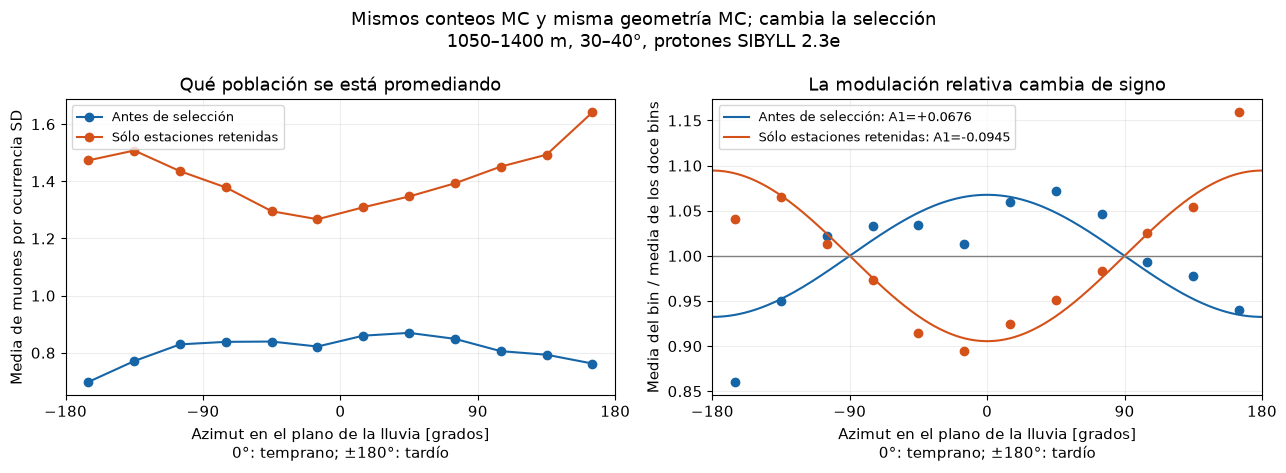

In [11]:
def label_phi_axis(axis):
    axis.set_xlim(-180, 180)
    axis.set_xticks([-180, -90, 0, 90, 180])
    axis.set_xlabel("Azimut en el plano de la lluvia [grados]\n0°: temprano; ±180°: tardío")


def save_figure(figure, name):
    """Sólo exporta dentro de exports/ de este notebook."""
    if SAVE_FIGURES:
        figure.savefig(EXPORT / (name + ".png"), bbox_inches="tight")
        figure.savefig(EXPORT / (name + ".pdf"), bbox_inches="tight")


fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
dense_phi = np.linspace(-np.pi, np.pi, 400)
for profile, amplitude, color, label in [
    (all_profile, A_all, COLORS["all"], "Antes de selección"),
    (kept_profile, A_kept, COLORS["kept"], "Sólo estaciones retenidas"),
]:
    axes[0].plot(PHI_DEGREES, profile["mean"], "o-", color=color, label=label)
    axes[1].plot(PHI_DEGREES, profile["normalized"], "o", color=color)
    axes[1].plot(np.rad2deg(dense_phi), harmonic(dense_phi, amplitude), color=color,
                 label=f"{label}: A1={amplitude:+.4f}")
axes[0].set_ylabel("Media de muones por ocurrencia SD")
axes[0].set_title("Qué población se está promediando")
axes[1].set_ylabel("Media del bin / media de los doce bins")
axes[1].set_title("La modulación relativa cambia de signo")
axes[1].axhline(1, color="gray", lw=1)
for ax in axes:
    label_phi_axis(ax)
    ax.legend(fontsize=9)
fig.suptitle("Mismos conteos MC y misma geometría MC; cambia la selección\n"
             "1050–1400 m, 30–40°, protones SIBYLL 2.3e")
fig.tight_layout()
save_figure(fig, "01_perfiles_antes_despues")
plt.show()

**Cómo leer la figura:** el promedio de la muestra seleccionada puede ser
mayor en ambos lados porque excluye muchas estaciones de baja ocupación.
La inversión describe la comparación RELATIVA temprano/tardío dentro de cada
muestra, no una comparación de sus normalizaciones globales.

No se cambiaron mu ni r ni phi de una estación. Tampoco se estimó el conteo
descartado a partir de su señal: ese conteo estaba guardado como verdad MC.

## 7. Cómo puede cambiar una media sin cambiar ningún muón

Definamos, dentro de cada bin azimutal:

- $\epsilon$: fracción de estaciones conservadas.
- $\epsilon_N$: fracción del total de muones que pertenece a esas estaciones.

Entonces, por simple aritmética,

\[
\overline N_{\mu,\mathrm{retenida}}
=\overline N_{\mu,\mathrm{todas}}\frac{\epsilon_N}{\epsilon}.
\]

Si se retienen principalmente estaciones ricas en muones, la fracción de
muones conservados puede ser mayor que la fracción de estaciones conservadas.
Si ese enriquecimiento cambia con phi, también cambia A1.

Ésta es una **identidad de selección**, no un modelo del disparo. Comprobarla
no prueba la causa electrónica de la selección. Sirve para ver exactamente
dónde cambia el promedio y por qué dividir sólo por el número de estaciones
no recupera automáticamente la población anterior.

In [12]:
selection_table = pd.DataFrame({
    "phi_deg": PHI_DEGREES,
    "n_all": all_profile["n"],
    "n_kept": kept_profile["n"],
    "mu_sum_all": all_profile["total"],
    "mu_sum_kept": kept_profile["total"],
    "mean_all": all_profile["mean"],
    "mean_kept": kept_profile["mean"],
})
selection_table["epsilon"] = selection_table["n_kept"] / selection_table["n_all"]
selection_table["epsilon_N"] = selection_table["mu_sum_kept"] / selection_table["mu_sum_all"]
selection_table["enrichment"] = selection_table["epsilon_N"] / selection_table["epsilon"]
selection_table["mean_from_identity"] = selection_table["mean_all"] * selection_table["enrichment"]
assert np.allclose(selection_table["mean_from_identity"], selection_table["mean_kept"])
display(selection_table[[
    "phi_deg", "epsilon", "epsilon_N", "enrichment", "mean_kept", "mean_from_identity"
]])
selection_table.to_csv(EXPORT / "seleccion_por_azimut.csv", index=False)

,phi_deg,epsilon,epsilon_N,enrichment,mean_kept,mean_from_identity
phi_bin,,,,,,
0,-165.0,0.24403,0.51493,2.11009,1.47331,1.47331
1,-135.0,0.27648,0.54054,1.95509,1.50769,1.50769
2,-105.0,0.37443,0.64788,1.73031,1.43536,1.43536
3,-75.0,0.44393,0.72993,1.64427,1.37846,1.37846
4,-45.0,0.50085,0.77291,1.54321,1.29536,1.29536
5,-15.0,0.51785,0.79839,1.54174,1.26723,1.26723
6,15.0,0.52225,0.79503,1.52231,1.30911,1.30911
7,45.0,0.50817,0.78695,1.54860,1.34687,1.34687
8,75.0,0.44496,0.73017,1.64098,1.39296,1.39296


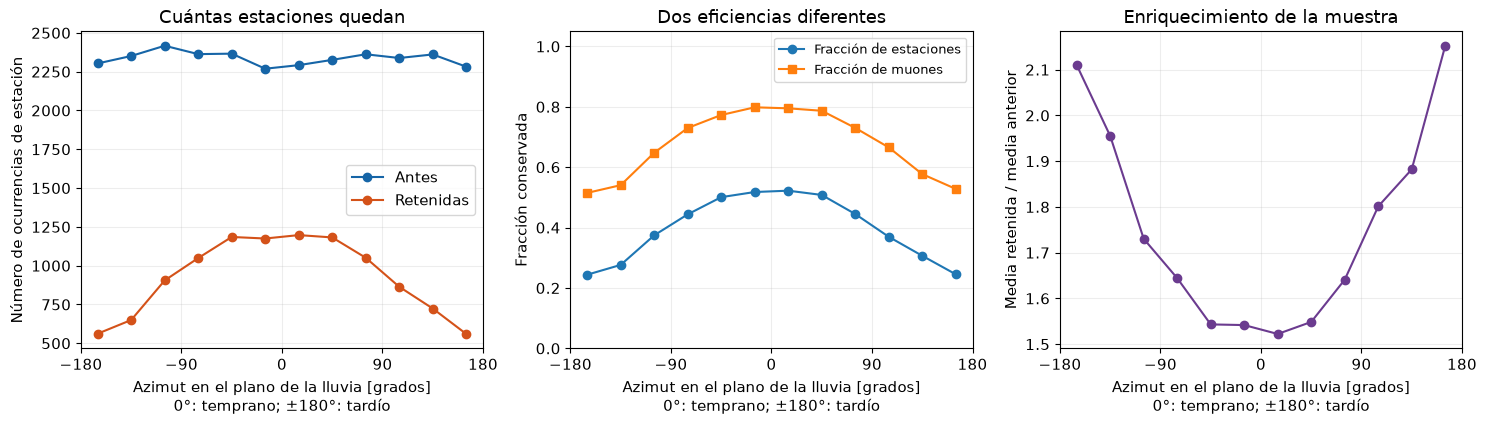

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
axes[0].plot(PHI_DEGREES, selection_table["n_all"], "o-", color=COLORS["all"], label="Antes")
axes[0].plot(PHI_DEGREES, selection_table["n_kept"], "o-", color=COLORS["kept"], label="Retenidas")
axes[0].set_ylabel("Número de ocurrencias de estación")
axes[0].set_title("Cuántas estaciones quedan")
axes[1].plot(PHI_DEGREES, selection_table["epsilon"], "o-", label="Fracción de estaciones")
axes[1].plot(PHI_DEGREES, selection_table["epsilon_N"], "s-", label="Fracción de muones")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Dos eficiencias diferentes")
axes[1].set_ylabel("Fracción conservada")
axes[2].plot(PHI_DEGREES, selection_table["enrichment"], "o-", color="#6b3b8f")
axes[2].set_ylabel("Media retenida / media anterior")
axes[2].set_title("Enriquecimiento de la muestra")
for ax in axes:
    label_phi_axis(ax)
axes[0].legend()
axes[1].legend(fontsize=9)
fig.tight_layout()
save_figure(fig, "02_eficiencia_y_enriquecimiento")
plt.show()

### Una vista alternativa: las distribuciones de conteos

Comparamos dos sectores de igual anchura: |phi|<60° (temprano) y |phi|>=120°
(tardío). No son sólo los puntos extremos ni sustituyen al ajuste de doce bins.
Las curvas siguientes muestran fracciones de estaciones con cada conteo,
incluyendo cero. Se normaliza cada distribución por su propio número de filas.
No utilizamos este gráfico para atribuir una causa al trigger.

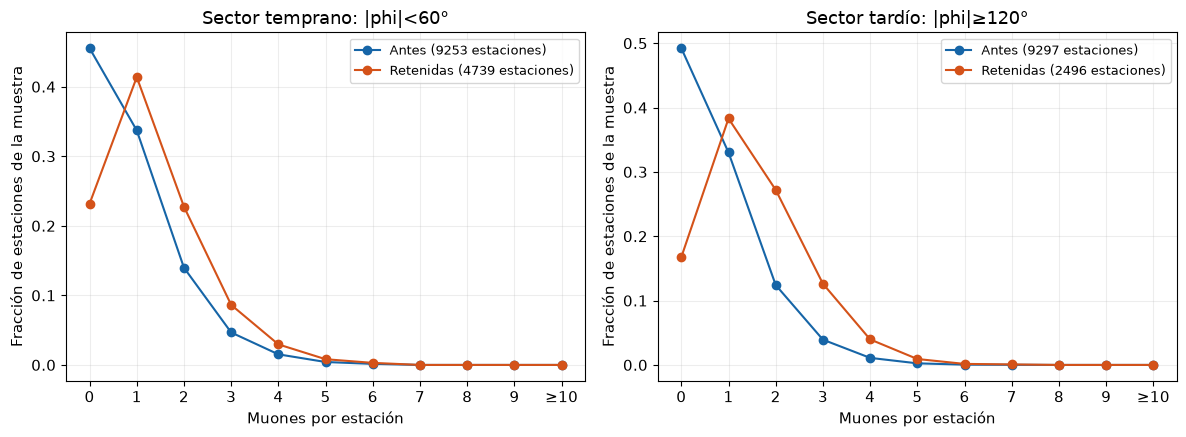

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
hist_edges = np.r_[np.arange(-0.5, 10.5, 1), np.inf]
hist_labels = [str(i) for i in range(10)] + ["≥10"]
for ax, title, sector in [
    (axes[0], "Sector temprano: |phi|<60°", np.abs(far["phi"]) < np.pi / 3),
    (axes[1], "Sector tardío: |phi|≥120°", np.abs(far["phi"]) >= 2 * np.pi / 3),
]:
    for keep_only, label, color in [
        (False, "Antes", COLORS["all"]), (True, "Retenidas", COLORS["kept"])
    ]:
        subset = far.loc[sector & ((far["has_rec"] == 1) if keep_only else True)]
        frequencies, _ = np.histogram(subset["mu"], bins=hist_edges)
        frequencies = frequencies / frequencies.sum()
        ax.plot(range(len(frequencies)), frequencies, "o-", color=color,
                label=f"{label} ({len(subset)} estaciones)")
    ax.set_xticks(range(len(hist_labels)), hist_labels)
    ax.set_xlabel("Muones por estación")
    ax.set_ylabel("Fracción de estaciones de la muestra")
    ax.set_title(title)
    ax.legend(fontsize=9)
fig.tight_layout()
save_figure(fig, "03_distribuciones_de_conteo")
plt.show()

## 8. Incertidumbre: remuestrear lluvias, no muones sueltos

Las estaciones de una lluvia están correlacionadas. Además, una lluvia de
biblioteca puede reutilizarse con diferentes núcleos. Tratar todas las filas
como independientes subestimaría esa dependencia.

Para reproducir el control anterior:

1. Quitamos el sufijo Use del identificador para agrupar reutilizaciones.
2. Compartimos el grupo entre archivos cuando el identificador remanente coincide.
3. Elegimos grupos con reemplazo y usamos **los mismos grupos** para antes y
   después de selección. Éste es el carácter pareado de la comparación.
4. Calculamos A1 de nuevo y guardamos también su diferencia.

Esta agrupación es operativa y conservadora respecto de las reutilizaciones
visibles. No es una certificación completa de genealogía de CORSIKA.

Los percentiles 2.5 y 97.5 de las réplicas definen el intervalo mostrado.
No se combinan dos errores independientes para la diferencia: las muestras
están anidadas y su covarianza importa.

Para que puedas seguir la implementación, sólo comprimimos cada grupo en
cuatro tablas de doce números: número de estaciones, suma de muones,
número de retenidas y suma de sus muones. Es exactamente la información que
se necesita para reconstruir las medias al remuestrear; no aproxima el conteo.

In [15]:
def paired_parent_bootstrap(table, rng, n_draws=800):
    """Bootstrap pareado de grupos de lluvia, explícito y serial."""
    parent_id = table["event_id"].str.replace(r":Use_\d+$", "", regex=True)
    parent_names, parent_index = np.unique(parent_id.to_numpy(), return_inverse=True)
    phi_index = azimuth_bin(table["phi"])
    kept = table["has_rec"].to_numpy(dtype=float)
    muons = table["mu"].to_numpy(dtype=float)
    n_parents = len(parent_names)

    # Matrices [grupo_de_lluvia, bin_phi]; np.add.at suma cada fila a su casillero.
    accumulated = []
    for row_value in [np.ones(len(table)), muons, kept, kept * muons]:
        group_table = np.zeros((n_parents, N_PHI))
        np.add.at(group_table, (parent_index, phi_index), row_value)
        accumulated.append(group_table)

    def means_for_weights(weights):
        n, total, n_kept, total_kept = [weights @ values for values in accumulated]
        if np.any(n <= 0) or np.any(n_kept <= 0):
            return None  # No inventamos medias para bins sin estaciones.
        return total / n, total_kept / n_kept

    original_means = means_for_weights(np.ones(n_parents))
    assert original_means is not None
    point_all = amplitude_from_means(original_means[0])
    point_kept = amplitude_from_means(original_means[1])

    draws = []
    for _ in range(n_draws):
        # Equivalente a sortear n_parents grupos con reemplazo y contar repeticiones.
        weights = rng.multinomial(n_parents, np.full(n_parents, 1 / n_parents))
        means = means_for_weights(weights)
        if means is None:
            continue
        before = amplitude_from_means(means[0])
        after = amplitude_from_means(means[1])
        draws.append([before, after, after - before])

    draws = np.asarray(draws)
    if len(draws) < 0.95 * n_draws:
        raise RuntimeError("Demasiadas réplicas sin soporte; revisar el bineado.")
    summary = []
    for index, (label, point) in enumerate([
        ("all", point_all), ("kept", point_kept), ("difference", point_kept - point_all)
    ]):
        summary.append({
            "quantity": label, "A1": point,
            "std_bootstrap": draws[:, index].std(ddof=1),
            "low95": np.quantile(draws[:, index], 0.025),
            "high95": np.quantile(draws[:, index], 0.975),
            "parents": n_parents, "valid_draws": len(draws),
        })
    return pd.DataFrame(summary), draws


# Misma semilla y orden de bandas que el ensayo final anterior.
# Cambiar la semilla cambia ligeramente percentiles, no los coeficientes centrales.
N_BOOTSTRAP = 800
rng = np.random.default_rng(110926)
radial_results = []
bootstrap_draws = {}
for r_min, r_max in RADIAL_BANDS:
    band = audit.loc[audit["r"].between(r_min, r_max, inclusive="left")]
    result, draws = paired_parent_bootstrap(band, rng, n_draws=N_BOOTSTRAP)
    result["r_min"], result["r_max"] = r_min, r_max
    result["stations_all"] = len(band)
    result["stations_kept"] = int(band["has_rec"].sum())
    radial_results.append(result)
    bootstrap_draws[(r_min, r_max)] = draws
    print(f"Terminado {r_min}–{r_max} m: {len(band):,} estaciones, {len(draws)} réplicas.")

radial_results = pd.concat(radial_results, ignore_index=True)
display(radial_results)
radial_results.to_csv(EXPORT / "A1_recalculado_con_bootstrap.csv", index=False)

Terminado 300–600 m: 10,357 estaciones, 800 réplicas.


Terminado 650–950 m: 17,730 estaciones, 800 réplicas.


Terminado 1050–1400 m: 28,030 estaciones, 800 réplicas.


Terminado 1400–1800 m: 38,432 estaciones, 800 réplicas.


,quantity,A1,std_bootstrap,low95,high95,parents,valid_draws,r_min,r_max,stations_all,stations_kept
0,all,0.06914,0.00671,0.05547,0.08116,960,800,300,600,10357,10357
1,kept,0.06914,0.00671,0.05547,0.08116,960,800,300,600,10357,10357
2,difference,0.00000,0.00000,0.00000,0.00000,960,800,300,600,10357,10357
3,all,0.06175,0.00797,0.04531,0.07793,960,800,650,950,17730,17250
4,kept,0.03972,0.00815,0.02275,0.05611,960,800,650,950,17730,17250
5,difference,-0.02203,0.00163,-0.02547,-0.01908,960,800,650,950,17730,17250
6,all,0.06764,0.00901,0.04937,0.08432,960,800,1050,1400,28030,11104
7,kept,-0.09453,0.01051,-0.11609,-0.07499,960,800,1050,1400,28030,11104
8,difference,-0.16216,0.00871,-0.17842,-0.14529,960,800,1050,1400,28030,11104
9,all,0.05795,0.01411,0.03045,0.08551,960,800,1400,1800,38432,1837


,A1,low95,high95,std_bootstrap,parents,valid_draws
quantity,,,,,,
all,0.06764,0.04937,0.08432,0.00901,960,800
kept,-0.09453,-0.11609,-0.07499,0.01051,960,800
difference,-0.16216,-0.17842,-0.14529,0.00871,960,800


**Resultado recalculado:** antes A1=+0.0676, después A1=-0.0945; ΔA1=-0.1622, IC 95% [-0.1784, -0.1453]. Positivo significa temprano. Este intervalo describe la muestra y el agrupamiento usados, no una ley universal para toda la producción.

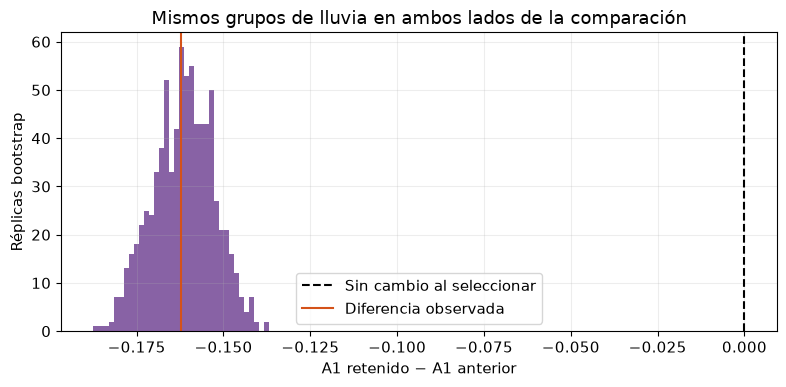

In [16]:
far_result = radial_results.loc[
    radial_results["r_min"].eq(FAR_MIN) & radial_results["r_max"].eq(FAR_MAX)
].set_index("quantity")
display(far_result[["A1", "low95", "high95", "std_bootstrap", "parents", "valid_draws"]])
delta = far_result.loc["difference"]
display(Markdown(
    f"**Resultado recalculado:** antes A1={A_all:+.4f}, después A1={A_kept:+.4f}; "
    f"ΔA1={delta['A1']:+.4f}, IC 95% "
    f"[{delta['low95']:+.4f}, {delta['high95']:+.4f}]. "
    "Positivo significa temprano. Este intervalo describe la muestra y el "
    "agrupamiento usados, no una ley universal para toda la producción."
))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(bootstrap_draws[(int(FAR_MIN), int(FAR_MAX))][:, 2], bins=35,
        color="#6b3b8f", alpha=0.8)
ax.axvline(0, color="black", ls="--", label="Sin cambio al seleccionar")
ax.axvline(delta["A1"], color=COLORS["kept"], label="Diferencia observada")
ax.set_xlabel("A1 retenido − A1 anterior")
ax.set_ylabel("Réplicas bootstrap")
ax.set_title("Mismos grupos de lluvia en ambos lados de la comparación")
ax.legend()
fig.tight_layout()
save_figure(fig, "04_bootstrap_pareado")
plt.show()

## 9. ¿Sucede en todos los radios?

Ahora se repite exactamente la comparación en las cuatro bandas de control.
Estas bandas no son todos los puntos de las figuras de tu capítulo 6:
fueron elegidas para la auditoría y se indican explícitamente.

Si todas las estaciones de un intervalo se conservan, antes y después deben
coincidir. A mayor radio puede caer la fracción conservada y cambiar qué
estaciones integran la media. No se presupone una relación causal simple
entre la caída de eficiencia y la amplitud: se muestran ambas por separado.

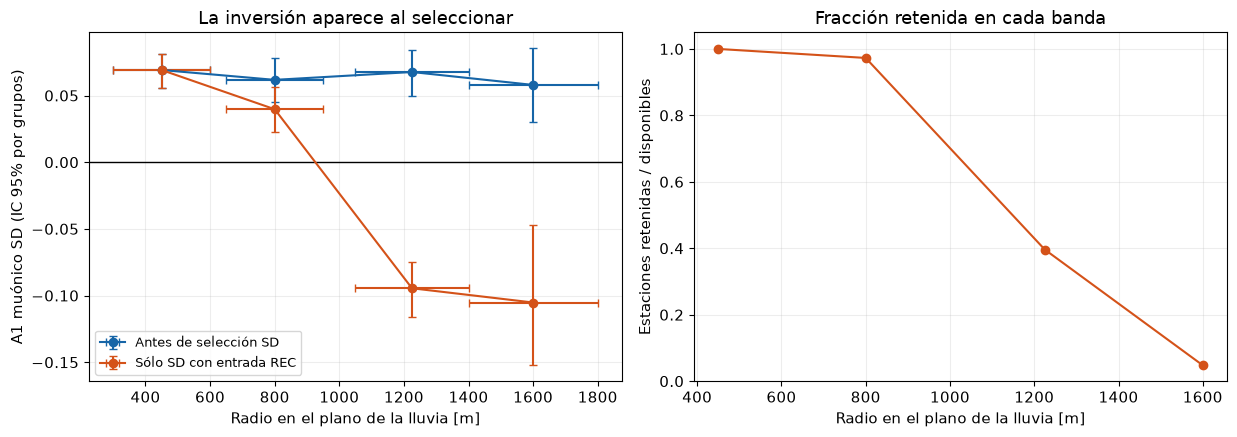

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
for quantity, label, color in [
    ("all", "Antes de selección SD", COLORS["all"]),
    ("kept", "Sólo SD con entrada REC", COLORS["kept"]),
]:
    rows = radial_results.loc[radial_results["quantity"] == quantity]
    mid = (rows["r_min"] + rows["r_max"]) / 2
    asymmetric_errors = np.vstack([rows["A1"] - rows["low95"], rows["high95"] - rows["A1"]])
    axes[0].errorbar(mid, rows["A1"], xerr=(rows["r_max"] - rows["r_min"]) / 2,
                     yerr=asymmetric_errors, fmt="o-", color=color, capsize=3, label=label)
rows = radial_results.loc[radial_results["quantity"] == "all"]
axes[1].plot((rows["r_min"] + rows["r_max"]) / 2,
             rows["stations_kept"] / rows["stations_all"], "o-", color=COLORS["kept"])
axes[0].axhline(0, color="black", lw=1)
axes[0].set_ylabel("A1 muónico SD (IC 95% por grupos)")
axes[0].set_title("La inversión aparece al seleccionar")
axes[0].legend(fontsize=9)
axes[1].set_ylabel("Estaciones retenidas / disponibles")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Fracción retenida en cada banda")
for ax in axes:
    ax.set_xlabel("Radio en el plano de la lluvia [m]")
fig.tight_layout()
save_figure(fig, "05_evolucion_radial")
plt.show()

## 10. Dónde entra la hipótesis electromagnética

Hasta aquí demostramos un **cambio del promedio al seleccionar**. No cambiamos
el trigger ni ejecutamos una versión alternativa de la reconstrucción.

Una interpretación física posible es:

1. La región temprana tiene mayor contribución EM.
2. Esa contribución puede ayudar a retener un tanque con pocos muones.
3. Con menor ayuda EM, la muestra tardía retenida puede quedar enriquecida en muones.

No se crea un muón adicional en la región tardía. Tampoco se cuentan electrones
como muones. La selección puede depender de una señal que contiene ambas especies.

Los perfiles EM y las fracciones de estaciones sin muones son **diagnósticos
compatibles con esa interpretación**, no una intervención causal que la pruebe.
El requisito HasStation incluye una cadena de procesos; no debe identificarse
automáticamente con un único umbral ni con "señal mayor que cero".

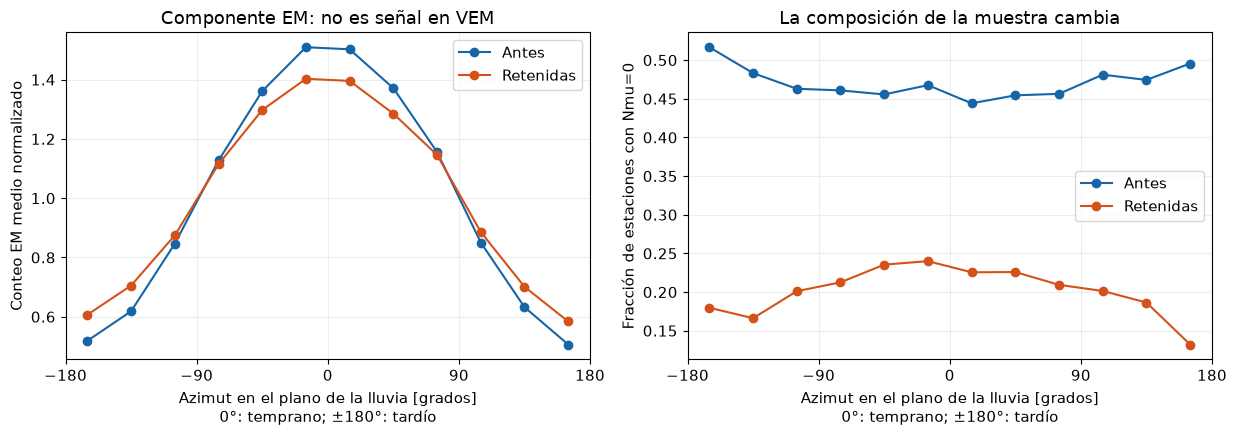

In [18]:
em_all = make_profile(far, "em")
em_kept = make_profile(kept_far, "em")
zero_mu_before = far.assign(phi_bin=azimuth_bin(far["phi"]), zero=far["mu"].eq(0)).groupby("phi_bin")["zero"].mean()
zero_mu_kept = kept_far.assign(phi_bin=azimuth_bin(kept_far["phi"]), zero=kept_far["mu"].eq(0)).groupby("phi_bin")["zero"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
axes[0].plot(PHI_DEGREES, em_all["normalized"], "o-", color=COLORS["all"], label="Antes")
axes[0].plot(PHI_DEGREES, em_kept["normalized"], "o-", color=COLORS["kept"], label="Retenidas")
axes[0].set_ylabel("Conteo EM medio normalizado")
axes[0].set_title("Componente EM: no es señal en VEM")
axes[1].plot(PHI_DEGREES, zero_mu_before, "o-", color=COLORS["all"], label="Antes")
axes[1].plot(PHI_DEGREES, zero_mu_kept, "o-", color=COLORS["kept"], label="Retenidas")
axes[1].set_ylabel("Fracción de estaciones con Nmu=0")
axes[1].set_title("La composición de la muestra cambia")
for ax in axes:
    label_phi_axis(ax)
    ax.legend()
fig.tight_layout()
save_figure(fig, "06_diagnosticos_EM_y_ceros")
plt.show()

In [19]:
# Mostrar también los estados REC: HasStation no es sinónimo de IsCandidate.
state_table = audit.groupby(["has_rec", "candidate", "silent"], dropna=False).agg(
    filas=("sdId", "size"), conteo_mu_medio=("mu", "mean")
).reset_index()
display(state_table)
print("Para has_rec=0, candidate/silent=0 son marcadores del extractor, no estados REC medidos.")
print("Una señal ausente no se rellena con cero ni se usa para definir esta selección.")

,has_rec,candidate,silent,filas,conteo_mu_medio
0,0,0,0,55249,0.32486
1,1,0,0,211,1.41232
2,1,0,1,16297,1.04350
3,1,1,0,34523,8.99076


Para has_rec=0, candidate/silent=0 son marcadores del extractor, no estados REC medidos.
Una señal ausente no se rellena con cero ni se usa para definir esta selección.


## 11. Volver a ver UMD y SD Total, sin cambiar qué mide cada uno

Para UMD se usa el conteo por módulo de tu parquet y su misma selección.
Para SD se usa una fila por estación. No sumamos módulos UMD y llamamos a eso
el mismo observable: se preserva la convención del análisis existente.

El SD Total es señal VEM; SD muones y SD EM son conteos. Sus coeficientes pueden
compararse, pero las amplitudes de conteos no se suman para predecir VEM.

El UMD de esta tabla sigue siendo **seleccionado**. No hemos obtenido aquí
el UMD de estaciones SD descartadas. Un A1 positivo no significa que su
población haya quedado libre de selección.

Esta banda ancha no coincide con un punto ideal r=1200 m, theta=35°.
En particular, no debe exigirse que su UMD reproduzca exactamente +0.11.

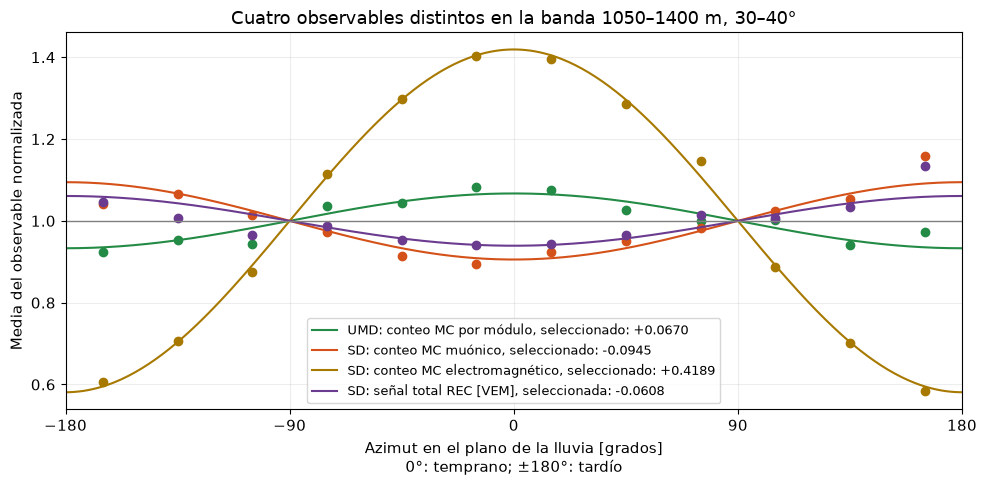

,observable,filas,A1
0,"UMD: conteo MC por módulo, seleccionado",33312,0.06698
1,"SD: conteo MC muónico, seleccionado",11104,-0.09453
2,"SD: conteo MC electromagnético, seleccionado",11104,0.41894
3,"SD: señal total REC [VEM], seleccionada",11104,-0.06079


In [20]:
module_far = modules.loc[
    modules["r_core_MC"].between(FAR_MIN, FAR_MAX, inclusive="left")
].copy()
observable_definitions = [
    ("UMD: conteo MC por módulo, seleccionado", module_far, "nMuones_MC", COLORS["umd"]),
    ("SD: conteo MC muónico, seleccionado", parquet_far, "sd_nMuons_MC", COLORS["kept"]),
    ("SD: conteo MC electromagnético, seleccionado", parquet_far, "sd_nEM_MC", "#a87900"),
    ("SD: señal total REC [VEM], seleccionada", parquet_far, "sdSignal_REC", "#6b3b8f"),
]
comparison_rows = []
fig, ax = plt.subplots(figsize=(10, 5))
for label, table, column, color in observable_definitions:
    profile = make_profile(table, column)
    amplitude = fit_profile(profile)
    comparison_rows.append({"observable": label, "filas": len(table), "A1": amplitude})
    ax.plot(PHI_DEGREES, profile["normalized"], "o", color=color)
    ax.plot(np.rad2deg(dense_phi), harmonic(dense_phi, amplitude), color=color,
            label=f"{label}: {amplitude:+.4f}")
ax.axhline(1, color="gray", lw=1)
ax.set_ylabel("Media del observable normalizada")
ax.set_title("Cuatro observables distintos en la banda 1050–1400 m, 30–40°")
label_phi_axis(ax)
ax.legend(fontsize=9)
fig.tight_layout()
save_figure(fig, "07_UMD_SD_observables_seleccionados")
plt.show()
comparison = pd.DataFrame(comparison_rows)
display(comparison)
comparison.to_csv(EXPORT / "observables_parquet_recalculados.csv", index=False)

## 12. Control de mezcla de radio, cenital y energía

Dentro de una banda ancha, cada azimut puede tener una mezcla diferente de
radios, energías y cenitales. Eso es un efecto distinto de que falten estaciones.

Este control divide la banda en celdas conjuntas:

- dos intervalos de energía;
- intervalos radiales de 50 m;
- dos intervalos cenitales.

Se conservan celdas con estaciones retenidas en TODOS los bins azimutales.
Se calcula cada media dentro de su celda y se vuelve a promediar con los
**mismos pesos de celda para todo phi y para ambas muestras**.

Los pesos corresponden a la distribución global de las estaciones disponibles
antes de selección, restringida al soporte común. No son pesos ajustados para
conseguir un signo. Este procedimiento no recupera las estaciones excluidas:
para conocer sus conteos sigue siendo necesaria la tabla ADST.

Este control reproduce los valores centrales del ensayo de estandarización
del informe. Aquí no se asigna a sus resultados el intervalo bootstrap de la
muestra no estandarizada: son estimadores diferentes.

In [21]:
standard = far.copy()
standard["energy_cell"] = pd.cut(
    standard["logE"], [17.49, 17.75, 18.01], labels=False
)  # Los bordes externos sólo encierran la banda 17.5–18.0 ya comprobada.
standard["radius_cell"] = pd.cut(
    standard["r"], np.arange(1050, 1401, 50), labels=False, right=False
)
standard["theta_cell"] = pd.cut(
    standard["theta"], [30, 35, 40], labels=False, right=False
)
standard["cell"] = (
    100 * standard["energy_cell"] + 10 * standard["radius_cell"] + standard["theta_cell"]
)
standard["phi_bin"] = azimuth_bin(standard["phi"])
cell_support = standard.loc[standard["has_rec"] == 1].groupby(
    ["cell", "phi_bin"]
).size().unstack(fill_value=0).reindex(columns=range(N_PHI), fill_value=0)
good_cells = cell_support.index[(cell_support > 0).all(axis=1)]
standard = standard.loc[standard["cell"].isin(good_cells)].copy()
cell_weights = standard.groupby("cell").size().sort_index()
cell_weights = cell_weights / cell_weights.sum()
display(cell_weights.rename("peso_comun").to_frame())
print("Celdas con soporte común:", len(cell_weights))
print("Filas incluidas:", len(standard), "de", len(far))

standardized_profiles = {}
for label, table in [
    ("Antes, mezcla común", standard),
    ("Retenidas, mezcla común", standard.loc[standard["has_rec"] == 1]),
]:
    means_per_cell = table.groupby(["cell", "phi_bin"])["mu"].mean().unstack()
    means_per_cell = means_per_cell.reindex(index=cell_weights.index, columns=range(N_PHI))
    assert np.isfinite(means_per_cell.to_numpy()).all()
    standardized_profiles[label] = cell_weights.to_numpy() @ means_per_cell.to_numpy()

standardized_results = pd.DataFrame([
    {"muestra": label, "A1": amplitude_from_means(means)}
    for label, means in standardized_profiles.items()
])
display(standardized_results)
standardized_results.to_csv(EXPORT / "control_mezcla_comun.csv", index=False)

,peso_comun
cell,
0,0.03061
1,0.03625
10,0.03093
11,0.03618
20,0.03411
21,0.03607
30,0.03389
31,0.03725
40,0.03371


Celdas con soporte común: 28
Filas incluidas: 28030 de 28030


,muestra,A1
0,"Antes, mezcla común",0.06948
1,"Retenidas, mezcla común",-0.10948


In [22]:
# Otro control fácil de interpretar: ventanas más estrechas. No se adjuntan CIs
# prestados de la banda ancha ni se interpreta cada signo como prueba independiente.
narrow_rows = []
for r0, r1, t0, t1 in [
    (1050, 1200, 30, 40), (1200, 1350, 30, 40),
    (1150, 1250, 34, 36), (1050, 1400, 30, 35), (1050, 1400, 35, 40),
]:
    narrow = audit.loc[
        audit["r"].between(r0, r1, inclusive="left")
        & audit["theta"].between(t0, t1, inclusive="left")
    ]
    for label, table in [("antes", narrow), ("retenidas", narrow.loc[narrow["has_rec"] == 1])]:
        narrow_rows.append({
            "r_min": r0, "r_max": r1, "theta_min": t0, "theta_max": t1,
            "muestra": label, "filas": len(table),
            "A1": fit_profile(make_profile(table, "mu")),
        })
narrow_results = pd.DataFrame(narrow_rows)
display(narrow_results)
narrow_results.to_csv(EXPORT / "control_bandas_estrechas.csv", index=False)

,r_min,r_max,theta_min,theta_max,muestra,filas,A1
0,1050,1200,30,40,antes,11368,0.06598
1,1050,1200,30,40,retenidas,6643,-0.07030
2,1200,1350,30,40,antes,12212,0.06601
3,1200,1350,30,40,retenidas,3694,-0.11392
4,1150,1250,34,36,antes,1635,0.07026
5,1150,1250,34,36,retenidas,679,-0.09422
6,1050,1400,30,35,antes,13427,0.06846
7,1050,1400,30,35,retenidas,5677,-0.06376
8,1050,1400,35,40,antes,14603,0.06716
9,1050,1400,35,40,retenidas,5427,-0.13027


## 13. ¿Por qué no hicimos exactamente lo mismo con UMD?

Porque la disponibilidad de verdad en ADST **no es idéntica para todos los
detectores**. El conteo SD previo a esa selección está guardado en las estaciones
simuladas. En el piloto UMD, los resúmenes de inyección poblados sólo aparecen
asociados a estaciones con contraparte SD reconstruida.

La auditoría del código encontró una ruta concreta de pérdida de información:
si no se crean ciertos canales electrónicos, la escritura del resumen no recorre
todos los centelladores simulados. Por eso:

> "No encuentro el resumen" no significa "entraron cero muones al módulo".

Lo comprobamos de forma legible con la tabla de módulos del piloto, sin extraer
una asimetría UMD previa a selección que estos datos no permiten calcular.
Ésta es una limitación de información disponible, no una prueba de que la
selección UMD sea nula o idéntica a la del SD.

In [23]:
umd_pilot_file = AUDIT / "umd_selection_raw.csv"
if umd_pilot_file.is_file():
    umd_pilot = pd.read_csv(umd_pilot_file, dtype={"source": str, "event_id": str})
    pilot_sources = umd_pilot["source"].unique()
    original_modules = modules.loc[
        modules["source"].isin(pilot_sources)
        & modules["r_core_MC"].between(150, 1800, inclusive="left")
    ].copy()
    module_key = KEY + ["moduleId"]
    checked_modules = original_modules.merge(
        umd_pilot[module_key + ["mu"]], on=module_key, how="left",
        validate="one_to_one",
    )
    present = checked_modules["mu"].notna()
    assert np.array_equal(
        checked_modules.loc[present, "mu"],
        checked_modules.loc[present, "nMuones_MC"],
    )
    # Verificamos el valor GUARDADO en parquet de resúmenes ausentes retenidos.
    # No lo usamos para rellenar los módulos de estaciones SD descartadas.
    assert checked_modules.loc[~present, "nMuones_MC"].eq(0).all()
    sd_pilot = audit.loc[audit["source"].isin(pilot_sources)]
    umd_availability = pd.DataFrame([
        {"comprobación": "Módulos con resumen UMD poblado en el piloto", "cantidad": len(umd_pilot)},
        {"comprobación": "De ellos, asociados a SD sin entrada REC", "cantidad": int(umd_pilot["has_rec"].eq(0).sum())},
        {"comprobación": "Filas de módulos del parquet retenido a cotejar", "cantidad": len(checked_modules)},
        {"comprobación": "Filas retenidas sin resumen UMD; parquet registra cero", "cantidad": int((~present).sum())},
        {"comprobación": "Ocurrencias SD descartadas en el mismo archivo", "cantidad": int(sd_pilot["has_rec"].eq(0).sum())},
    ])
    display(umd_availability)
    display(umd_pilot[["sdId", "counterId", "moduleId", "mu", "area", "has_rec"]].head(8))
    print("No calculamos UMD antes de selección: sus resúmenes faltantes no son ceros físicos demostrados.")
else:
    print("No está el CSV del piloto UMD. Su ausencia NO se convierte en conteo cero.")
    print("El resultado SD anterior no depende de cargar este piloto.")

,comprobación,cantidad
0,Módulos con resumen UMD poblado en el piloto,5507
1,"De ellos, asociados a SD sin entrada REC",0
2,Filas de módulos del parquet retenido a cotejar,7632
3,Filas retenidas sin resumen UMD; parquet regis...,2125
4,Ocurrencias SD descartadas en el mismo archivo,2752


,sdId,counterId,moduleId,mu,area,has_rec
0,4213,104213,1,1,10.496,1
1,4213,104213,2,4,10.496,1
2,4213,104213,3,2,10.496,1
3,4212,104212,1,0,10.496,1
4,4212,104212,2,0,10.496,1
5,4212,104212,3,1,10.496,1
6,4054,104054,1,2,10.496,1
7,4054,104054,2,3,10.496,1


No calculamos UMD antes de selección: sus resúmenes faltantes no son ceros físicos demostrados.


## 14. Cómo encajan los efectos físicos que ya habías trabajado

| Efecto | Qué cambia | Signo / límite de la interpretación |
|---|---|---|
| Supervivencia atmosférica | Decaimiento, energía y alcance de una misma población producida | El trayecto tardío adicional favorece pérdidas: contribución temprana |
| Proyección/apertura | Cuánta superficie interceptan las direcciones locales | Para flujo saliente, la proyección de placa favorece temprano; el tanque tiene tapa y lateral |
| Dilución espacial | El área ocupada por partículas de una fuente al aumentar su recorrido | El mayor recorrido tardío diluye: contribución temprana |
| Distribución angular | El ángulo de emisión necesario para llegar al mismo radio | Un ángulo tardío menor puede muestrear una distribución más poblada: contribución tardía |
| Selección de estaciones | Qué estaciones participan en la media | El signo se mide; en este control produce la inversión SD |

Proyección y distribución angular **no son el mismo término con dos nombres**.
Un menor momento longitudinal no vuelve negativo un cociente radial saliente.
La ganancia angular tardía tampoco domina necesariamente la dilución y la
supervivencia después de integrar todas las energías y alturas.

Lo nuevo aquí es la última fila: una operación sobre la muestra, acoplada a
la respuesta física del detector. No es un proceso nuevo de producción de muones.

Para UMD, el suelo cambia población, energía y dirección aceptadas. Además,
un muón del módulo no es en general el que atraviesa el tanque cercano. La
correlación de la selección SD con cada conteo puede ser diferente; no está
demostrada su independencia.

La discusión física completa, separada de los números de modelos ilustrativos,
está en [physics_explanation.html](../../01_fisica/physics_explanation.html).
Los supuestos, fuentes primarias y auditoría de Offline están en
[report.html](../../01_fisica/report.html).
No se necesita leer esos documentos para reproducir el control de este notebook.

## 15. Comprobaciones finales: reproducir no es cargar una respuesta

A esta altura todos los coeficientes y gráficos se obtuvieron de filas de datos.
Las constantes de la siguiente celda son **sólo valores de referencia para
detectar que se está utilizando la misma muestra**, no insumos del ajuste.

Si cambiás las bandas, archivos o ponderación, pueden dejar de coincidir.
No ajustes los datos para volver a conseguirlas. Primero revisá la definición
del observable y la procedencia de los archivos.

El intervalo bootstrap mostrado es pareado; su semilla y orden de llamadas
están explícitos arriba. Cambiar sólo la semilla puede mover sus últimos dígitos.

In [24]:
reference_points = {
    (300, 600): (+0.0691383703, +0.0691383703),
    (650, 950): (+0.0617545334, +0.0397238431),
    (1050, 1400): (+0.0676378932, -0.0945270165),
    (1400, 1800): (+0.0579534494, -0.1052094357),
}
same_reference_scope = raw["source"].nunique() == 20 and len(raw) == 106280
validation_rows = []
if same_reference_scope:
    for band, (expected_before, expected_after) in reference_points.items():
        rows = radial_results.loc[radial_results["r_min"].eq(band[0])].set_index("quantity")
        ok = np.isclose(rows.loc["all", "A1"], expected_before, atol=1e-8, rtol=0)
        ok &= np.isclose(rows.loc["kept", "A1"], expected_after, atol=1e-8, rtol=0)
        validation_rows.append({"comprobación": f"A1 de referencia, {band[0]}–{band[1]} m", "pasa": bool(ok)})
        assert ok
else:
    print("La extracción no tiene el tamaño del control de veinte archivos; no se exige su resultado.")
validation_rows += [
    {"comprobación": "Conteos ADST y parquet emparejados idénticos", "pasa": bool(
        np.array_equal(matched["mu"], matched["sd_nMuons_MC"]))},
    {"comprobación": "A1 del corte HasStation coincide con parquet", "pasa": bool(
        np.isclose(A_kept, A_parquet, atol=1e-10))},
    {"comprobación": "Identidad de selección por bin", "pasa": bool(
        np.allclose(selection_table["mean_kept"], selection_table["mean_from_identity"]))},
]
display(pd.DataFrame(validation_rows))
pd.DataFrame(validation_rows).to_csv(EXPORT / "comprobaciones.csv", index=False)
central_result.to_csv(EXPORT / "resultado_principal.csv", index=False)

,comprobación,pasa
0,"A1 de referencia, 300–600 m",True
1,"A1 de referencia, 650–950 m",True
2,"A1 de referencia, 1050–1400 m",True
3,"A1 de referencia, 1400–1800 m",True
4,Conteos ADST y parquet emparejados idénticos,True
5,A1 del corte HasStation coincide con parquet,True
6,Identidad de selección por bin,True


## 16. Conclusión que permiten estos datos

**Establecido en este control:** dentro de los eventos ADST escritos y de la
banda estudiada, conservar sólo estaciones con objeto SD reconstruido cambia
el signo del promedio de conteos muónicos. Los conteos y coordenadas de las
filas conservadas coinciden con el parquet.

**No establecido:** que el algoritmo reconstruya incorrectamente el número
de muones; que toda la causa sea un trigger particular; que la ayuda EM haya
sido aislada mediante una intervención; que la señal VEM obedezca al mismo
peso que un conteo; o que esté cerrado el caso UMD.

**Lo que cambia en la interpretación:** no hay que exigir a un modelo de flujo
no seleccionado que reproduzca directamente el promedio de una muestra
seleccionada. Primero se deben comparar observables y poblaciones equivalentes.

Para tu pregunta original:

> Sí había información adicional accesible: la verdad MC por estación en
> los ADST originales, que el lector no conservaba para ciertas estaciones.
> No apareció información nueva de producción individual y no se volvió a
> ejecutar la reconstrucción. Cambió el acceso a registros ya guardados.

---

## Apéndice A. Leer los .root originales vos mismo

El análisis precedente usa la tabla de estaciones como caché de lectura.
Para no convertirla en una "caja negra", el extractor nuevo es corto, serial,
ampliamente comentado y se muestra completo abajo. Su parte esencial es:

~~~python
for sim_station in sd_event.GetSimStationVector():
    n_mu = sim_station.GetNumberOfMuons()
    has_rec = sd_event.HasStation(sim_station.GetId())
    # Guardar AMBAS cosas, incluso si has_rec es False.
~~~

Se leen geometría y conteos ya escritos. No se llama a módulos de simulación
ni reconstrucción. Los filtros son explícitos: 30–40° MC, radio 150–1800 m,
los IDs SD usados en la auditoría, y los archivos de la banda energética.

**Entornos:** el venv permite analizar pandas y hacer gráficos. Leer estos
ADST requiere además los diccionarios de Offline y una versión compatible de
ROOT. El extractor se ejecuta en un proceso separado con el ROOT6 probado en
este servidor. Así no se mezclan bibliotecas ROOT incompatibles en el kernel.

Nada impide hacerlo desde tu propio kernel Offline si tiene esas bibliotecas;
separar procesos evita exigir que cambies el kernel de todo el notebook.

No alcanza con llamar GetNumberOfMuons sobre un objeto REC: primero hay que
acceder a la colección de estaciones **simuladas**.

In [25]:
extractor_path = HERE / "read_original_adst.py"
display(Code(extractor_path.read_text(encoding="utf-8"), language="python"))

"""Readable, serial extraction of SD simulation counts from EXISTING ADST files.

This is NOT CORSIKA, Geant4, or reconstruction. It reads saved objects using the
Offline/ROOT6 dictionaries. It deliberately does NOT require HasStation before
reading a simulated station's count. See the companion notebook for the analysis.

Safety: writes only into a NEW subdirectory of this walkthrough folder. It never
overwrites the forensic-review cache, the parquet, a ROOT input, or the thesis.
The full extraction is opt-in; default is one file and fifty saved events.
"""
import argparse
import csv
import math
from pathlib import Path
import time


HERE = Path(__file__).resolve().parent
DEFAULT_INPUT = Path(
    '/srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/'
    'MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/proton'
)
DEFAULT_LIBRARY = Path('/opt/auger/offline/icrc2025-test7-root6/lib/libRecEventKG.so')


def shower_plane_coordinates(position, core, zenith, azimuth):
    """Return r [m] and early/late phi [rad] from SITE-coordinate positions.

    This explicitly implements RotateZ(-azimuth), then RotateY(-zenith), as in
    the original audited reader. No reconstructed core enters this calculation.
    The resulting phi=0 points early. We check it against the parquet separately.
    """
    dx = position.X() - core.X()
    dy = position.Y() - core.Y()
    dz = position.Z() - core.Z()
    x_after_z = math.cos(azimuth) * dx + math.sin(azimuth) * dy
    y_after_z = -math.sin(azimuth) * dx + math.cos(azimuth) * dy
    x_plane = math.cos(zenith) * x_after_z - math.sin(zenith) * dz
    y_plane = y_after_z
    return math.hypot(x_plane, y_plane), math.atan2(y_plane, x_plane)


def enable_needed_branches(reader):
    """Read counts/positions/status, not PMT traces or per-particle lists.

    This only reduces file I/O. Branches below describe the existing ROOT schema;
    they are not physics cuts. Both reconstructed and simulated station vectors
    are enabled, including their IDs so that HasStation can answer correctly.
    """
    branches = [
        'event.fEventId',
        'event.fGenShower.fEnergy',
        'event.fGenShower.fCoreSiteCS*',
        'event.fGenShower.fAxisCoreCS*',
        'event.fSDEvent.fStations',
        'event.fSDEvent.fGenStations',
    ]
    branches += [
        'event.fSDEvent.fStations.' + name
        for name in ['fId', 'fStatus', 'fTriggerBits', 'fTotalSignal']
    ]
    branches += [
        'event.fSDEvent.fGenStations.' + name
        for name in ['fId', 'fNumberOfMuons', 'fNumberOfElectrons',
                     'fNumberOfPhotons', 'fThinning', 'fUsedWeight',
                     'fInsideMinRadius']
    ]
    reader.SetBranchStatus('*', False)
    for branch in branches:
        reader.SetBranchStatus(branch, True)


def main():
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument('--input-dir', type=Path, default=DEFAULT_INPUT)
    parser.add_argument('--library', type=Path, default=DEFAULT_LIBRARY)
    parser.add_argument('--max-files', type=int, default=1)
    parser.add_argument('--max-events', type=int, default=50,
                        help='Saved events per file; 0 means all. Default: 50.')
    parser.add_argument('--output-dir', type=Path, required=True,
                        help='NEW directory inside this walkthrough folder.')
    args = parser.parse_args()
    if not 1 <= args.max_files <= 20 or args.max_events < 0:
        parser.error('Use 1..20 files and max-events >= 0; extraction is serial.')
    output = args.output_dir.resolve()
    if output == HERE or not output.is_relative_to(HERE):
        parser.error('Output must be a NEW subdirectory inside ' + str(HERE))
    if output.exists():
        parser.error('Output already exists. Choose another name; nothing overwritten.')
    files = sorted(args.input_dir.glob('*.root'))[:args.max_files]
    if len(files) != args.max_files:
        parser.error('Not enough input ROOT files in the selected directory

### A.1. Prueba pequeña de lectura, y después comparación contra la caché

Por defecto este bloque NO relee ROOT. Podés activarlo deliberadamente.
La primera prueba lee como máximo cincuenta eventos guardados de un archivo.
No tiene por qué reproducir el A1 de veinte archivos; comprueba los registros.

Para regenerar la muestra completa:

- usar max_files=20 y max_events=0;
- confirmar explícitamente la lectura completa en la variable indicada;
- esperar el costo de I/O serial (referencia histórica: varios minutos);
- cambiar RAW_STATION_TABLE al nuevo stations.csv y volver a ejecutar desde arriba.

El extractor rechaza un directorio de salida ya existente. Nunca reemplaza
la extracción completa con una prueba parcial ni modifica los .root.

Si estas rutas de ROOT6 no existen en tu máquina, usá un entorno Offline
compatible. No instales un ROOT arbitrario suponiendo que abrirá estos ADST.

In [26]:
REREAD_ADST = False             # Cambiar a True sólo cuando quieras releer ROOT.
RAW_MAX_FILES = 1
RAW_MAX_EVENTS = 50             # 0 significa todos los eventos del archivo.
CONFIRM_FULL_READ = False       # Requerido si pedís más de un archivo.

ROOT6_PYTHON = Path("/usr/bin/python3")
ROOT6_MODULES = Path("/srv/software/amd64/ubuntu/24.04/external/root/6.30.04/lib")
OFFLINE_LIB = Path("/opt/auger/offline/icrc2025-test7-root6/lib")

if REREAD_ADST:
    import subprocess
    from datetime import datetime
    from uuid import uuid4

    if RAW_MAX_FILES > 1 and not CONFIRM_FULL_READ:
        raise RuntimeError("Confirmá explícitamente el costo de releer varios archivos.")
    for path in [ROOT6_PYTHON, ROOT6_MODULES, OFFLINE_LIB / "libRecEventKG.so", ADST_DIR]:
        if not path.exists():
            raise FileNotFoundError(f"Revisá el entorno compatible de ROOT6: {path}")

    # Una salida nueva por ejecución: imposible pisar la caché anterior por accidente.
    extraction_dir = HERE / "extractions" / (
        datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid4().hex[:8]
    )
    environment = os.environ.copy()
    environment["PYTHONPATH"] = str(ROOT6_MODULES)
    environment["LD_LIBRARY_PATH"] = str(ROOT6_MODULES) + ":" + str(OFFLINE_LIB)
    command = [
        str(ROOT6_PYTHON), "-u", str(extractor_path),
        "--input-dir", str(ADST_DIR),
        "--max-files", str(RAW_MAX_FILES),
        "--max-events", str(RAW_MAX_EVENTS),
        "--output-dir", str(extraction_dir),
    ]
    print("Comando (cada elemento es un argumento, sin shell):")
    display(command)
    print("Directorio nuevo:", extraction_dir)
    # Un solo proceso. El stdout informa el avance archivo por archivo.
    process = subprocess.Popen(command, env=environment, stdout=subprocess.PIPE,
                               stderr=subprocess.STDOUT, text=True)
    for line in process.stdout:
        print(line, end="", flush=True)
    if process.wait() != 0:
        raise RuntimeError("Falló la lectura ROOT. No se cambia la tabla usada arriba.")
    new_station_file = extraction_dir / "stations.csv"
    print("\nPara recalcular desde esta lectura, apuntá RAW_STATION_TABLE a:", new_station_file)
else:
    print("Lectura ROOT desactivada. Run All no lanza un barrido de ADST.")

Lectura ROOT desactivada. Run All no lanza un barrido de ADST.


### A.2. Control sobre una lectura fresca pequeña incluida en esta entrega

Durante la preparación de este notebook se ejecuta una prueba acotada del
extractor nuevo. Si existe su tabla, se comparan TODAS sus filas con la caché:
IDs, conteos, condición de presencia, radio y azimut.

Se muestra también su tabla de procedencia con el número de eventos leídos.
Esto es un control independiente de lectura en una submuestra, no una nueva
extracción completa de veinte archivos. Si no existe la prueba local, el
cuaderno lo declara; no simula haber ejecutado ROOT.

In [27]:
fresh_file = HERE / "raw_smoke_test/stations.csv"
fresh_provenance_file = HERE / "raw_smoke_test/provenance.csv"
if fresh_file.is_file() and fresh_provenance_file.is_file():
    display(pd.read_csv(fresh_provenance_file))
    fresh = pd.read_csv(fresh_file, dtype={"source": str, "event_id": str})
    if len(fresh) == 0:
        raise RuntimeError("El piloto no produjo filas; no sirve como validación.")
    reread_match = fresh.merge(
        raw[KEY + ["mu", "em", "has_rec", "r", "phi"]],
        on=KEY, how="left", validate="one_to_one",
        suffixes=("_fresh", "_cache"), indicator=True,
    )
    assert reread_match["_merge"].eq("both").all()
    for name in ["mu", "em", "has_rec"]:
        assert np.array_equal(reread_match[name + "_fresh"], reread_match[name + "_cache"])
    delta_r = np.max(np.abs(reread_match["r_fresh"] - reread_match["r_cache"]))
    delta_phi = np.max(np.abs(np.angle(np.exp(1j * (
        reread_match["phi_fresh"] - reread_match["phi_cache"]
    )))))
    assert delta_r < 1e-6 and delta_phi < 1e-8
    display(pd.DataFrame([
        {"comprobación": "Filas leídas de nuevo y cotejadas", "resultado": len(fresh)},
        {"comprobación": "Filas frescas sin objeto SD reconstruido", "resultado": int(fresh["has_rec"].eq(0).sum())},
        {"comprobación": "Conteos o has_rec distintos", "resultado": 0},
        {"comprobación": "Máxima diferencia de r [m]", "resultado": delta_r},
        {"comprobación": "Máxima diferencia circular de phi [rad]", "resultado": delta_phi},
    ]))
else:
    print("No hay piloto ROOT fresco local. El resto del notebook recalcula desde la caché indicada.")

,source,input_path,input_bytes,events_read,events_in_zenith_band,station_rows,elapsed_seconds
0,SIB23e_175_180_proton_MdSdInfill_CORSIKA78010_...,/srv/data/Malargue/icrc2025/test7/IdealMC_CORS...,9723803016,50,9,200,6.78885


,comprobación,resultado
0,Filas leídas de nuevo y cotejadas,200.0
1,Filas frescas sin objeto SD reconstruido,105.0
2,Conteos o has_rec distintos,0.0
3,Máxima diferencia de r [m],0.0
4,Máxima diferencia circular de phi [rad],0.0


## Apéndice B. Límites y trazabilidad de las afirmaciones de código

Hay tres niveles de evidencia, que no conviene confundir:

1. **Este notebook** vuelve a calcular el efecto de seleccionar estaciones.
2. **La prueba ROOT** verifica que esos registros existen en los ADST originales.
3. **La auditoría del código de Offline** identifica cómo se incrementa el
   contador y cómo se escribe el resumen; no se vuelve a simular el detector.

Las partes pertinentes del código inspeccionado son:

- Framework/SEvent/Station.cc: aceptación geométrica IsHit y llamada a CountParticle.
- Framework/SEvent/StationSimData.cc: incremento por especie, sin umbral de luz.
- SD2ADST.cc: copia del contador al objeto que se escribe en ADST.
- MD2ADST.cc y MdOptoElectronicSimulator.cc: relación entre canales electrónicos
  y disponibilidad del resumen de simulación UMD.

El árbol local inspeccionado tiene la etiqueta de producción correspondiente;
eso no equivale a una prueba binaria de qué build produjo cada evento.
El cotejo directo de registros es un control adicional, de naturaleza distinta.

Tampoco hay que aplicar al UMD un umbral o efecto del agua inferido para el SD.
Agua, suelo, plano sensible y definición del conteo no son intercambiables.

**Avisos reales de ROOT en la prueba pequeña:** el diccionario instalado emite
advertencias de checksum/esquema para Detector (un mapa de apuntado FD) y
RdRecStationParameterStorageMap. El lector no las oculta y no escribe objetos
ROOT. El cotejo fresco verifica específicamente los conteos, la presencia SD
y las coordenadas que usamos; no certifica compatibilidad de todos los campos
FD/RD ni autoriza reescribir esos archivos con este diccionario.

Los detalles de esa auditoría y sus referencias están en el informe enlazado
arriba. Los scripts comprimidos anteriores quedan como registro histórico,
pero no se importan ni se ejecutan para calcular los resultados de este notebook.

In [28]:
# Una ficha pequeña, legible, para saber qué ejecución estás mirando.
def sha256_stream(path):
    """Huella del archivo de filas, sin cargar todo el CSV otra vez en memoria."""
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


execution_card = pd.DataFrame([
    {"campo": "Tabla por estación utilizada", "valor": str(RAW_STATION_TABLE)},
    {"campo": "SHA256 de esa tabla (identidad del insumo, no prueba física)", "valor": sha256_stream(RAW_STATION_TABLE)},
    {"campo": "Archivos representados", "valor": raw["source"].nunique()},
    {"campo": "Filas ADST analizadas", "valor": len(raw)},
    {"campo": "Réplicas bootstrap por banda", "valor": N_BOOTSTRAP},
    {"campo": "Relectura opcional de ROOT activada en este Run All", "valor": REREAD_ADST},
    {"campo": "Segundos del recorrido del notebook", "valor": round(time.monotonic() - started_notebook, 2)},
    {"campo": "Salidas nuevas", "valor": str(EXPORT)},
])
display(execution_card)
execution_card.to_csv(EXPORT / "ficha_de_ejecucion.csv", index=False)

,campo,valor
0,Tabla por estación utilizada,/home/lsilva/Github/Tesis-de-Licenciatura---IT...
1,"SHA256 de esa tabla (identidad del insumo, no ...",8a62ff0737dd6f6f2322782398c61e8bd37fb13cc46498...
2,Archivos representados,20
3,Filas ADST analizadas,106280
4,Réplicas bootstrap por banda,800
5,Relectura opcional de ROOT activada en este Ru...,False
6,Segundos del recorrido del notebook,18.85
7,Salidas nuevas,/home/lsilva/Github/Tesis-de-Licenciatura---IT...


### Si un resultado no coincide

- Revisá primero **qué archivos, bandas y unidad de fila** estás usando.
- Comprobá la fase comparando ángulos entre ADST y parquet, no mirando el signo.
- No elimines mu=0 ni conviertas información UMD ausente en cero físico.
- No cambies silenciosamente entre ajuste ponderado y no ponderado.
- No confundas una prueba ROOT parcial con la extracción completa.
- No interpretes un valor MC leído sólo en estaciones retenidas como una
  medición automática de toda la población incidente.

La pregunta que debe quedar visible al cerrar el cuaderno es:

**¿Estoy estudiando las partículas que llegaron a estaciones simuladas
disponibles, o las partículas de las estaciones que mi selección dejó pasar?**

Esa diferencia es el hallazgo demostrado aquí. La física detallada del disparo
y la explicación completa del UMD siguen necesitando controles adicionales.